In [7]:
import scipy.io as sio
import numpy as np

data_path = "./data/meas_gre_dir1.mat"

mat_data = sio.loadmat(data_path)

print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'B0_dir', 'CF', 'delta_TE', 'mask_brain', 'meas_gre', 'te_gre', 'tolvalue', 'voxel_size_gre'])


In [8]:
for key in mat_data.keys():
    if not key.startswith("__"):
        value = mat_data[key]

        print(f"\n[{key}]")
        print("shape:", value.shape)
        print("dtype:", value.dtype)

        if value.size < 20:
            print("value:", value)


[B0_dir]
shape: (1, 3)
dtype: uint8
value: [[0 0 1]]

[CF]
shape: (1, 1)
dtype: int32
value: [[123177385]]

[delta_TE]
shape: (1, 1)
dtype: float64
value: [[0.00503]]

[mask_brain]
shape: (256, 224, 176)
dtype: uint8

[meas_gre]
shape: (256, 224, 176, 6)
dtype: complex128

[te_gre]
shape: (6, 1)
dtype: float64
value: [[0.0077 ]
 [0.01273]
 [0.01776]
 [0.02279]
 [0.02782]
 [0.03285]]

[tolvalue]
shape: (1, 1)
dtype: float64
value: [[1.e-05]]

[voxel_size_gre]
shape: (3, 1)
dtype: uint8
value: [[1]
 [1]
 [1]]


In [9]:
# 데이터 추출
meas_gre = mat_data["meas_gre"]
mask = mat_data["mask_brain"]

print("meas_gre shape:", meas_gre.shape)
print("mask shape:", mask.shape)
print("dtype:", meas_gre.dtype)

meas_gre shape: (256, 224, 176, 6)
mask shape: (256, 224, 176)
dtype: complex128


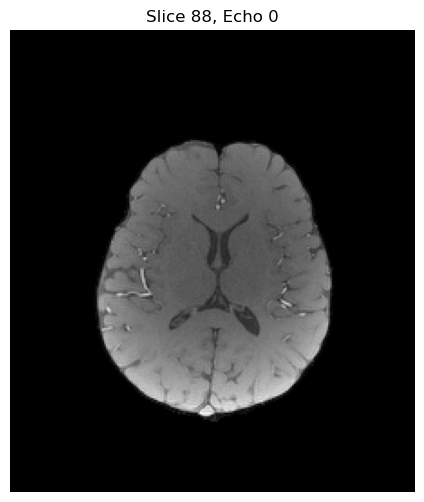

In [4]:
import matplotlib.pyplot as plt

echo = 0

magnitude = np.abs(
    meas_gre[:, :, slice_idx, echo]
)

plt.figure(figsize=(6,6))
plt.imshow(magnitude, cmap="gray")
plt.title(f"Slice {slice_idx}, Echo {echo}")
plt.axis("off")
plt.show()

In [6]:
for key in mat_data.keys():
    if not key.startswith("__"):
        print("\n===== ", key, " =====")
        print(type(mat_data[key]))
        print("shape:", np.shape(mat_data[key]))


=====  B0_dir  =====
<class 'numpy.ndarray'>
shape: (1, 3)

=====  CF  =====
<class 'numpy.ndarray'>
shape: (1, 1)

=====  delta_TE  =====
<class 'numpy.ndarray'>
shape: (1, 1)

=====  mask_brain  =====
<class 'numpy.ndarray'>
shape: (256, 224, 176)

=====  meas_gre  =====
<class 'numpy.ndarray'>
shape: (256, 224, 176, 6)

=====  te_gre  =====
<class 'numpy.ndarray'>
shape: (6, 1)

=====  tolvalue  =====
<class 'numpy.ndarray'>
shape: (1, 1)

=====  voxel_size_gre  =====
<class 'numpy.ndarray'>
shape: (3, 1)


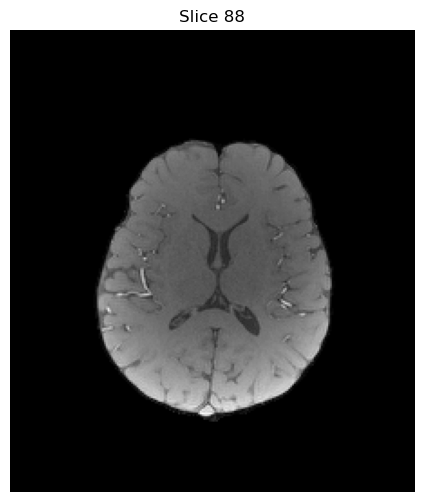

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터
meas_gre = mat_data["meas_gre"]

# 중간 slice
slice_idx = meas_gre.shape[2] // 2

# 첫 번째 echo
image = np.abs(meas_gre[:, :, slice_idx, 0])

plt.figure(figsize=(6,6))
plt.imshow(image, cmap="gray")
plt.title(f"Slice {slice_idx}")
plt.axis("off")
plt.show()

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터
meas_gre = mat_data["meas_gre"]
mask = mat_data["mask_brain"]

# 확인할 slice / echo
slice_idx = 88
echo = 0

# magnitude 변환
magnitude = np.abs(meas_gre[:, :, slice_idx, echo])

# mask slice
mask_slice = mask[:, :, slice_idx]

# mask 적용
masked_magnitude = magnitude * mask_slice


print("===== 전체 영역 =====")
print("원본 평균:", np.mean(magnitude))
print("mask 적용 평균:", np.mean(masked_magnitude))

print("\n===== mask 영역 내부 =====")
print("원본(mask=1) 평균:", np.mean(magnitude[mask_slice == 1]))
print("mask 적용(mask=1) 평균:", np.mean(masked_magnitude[mask_slice == 1]))

print("\n===== mask 영역 외부 =====")
print("원본(mask=0) 평균:", np.mean(magnitude[mask_slice == 0]))
print("mask 적용(mask=0) 평균:", np.mean(masked_magnitude[mask_slice == 0]))


===== 전체 영역 =====
원본 평균: 1.1313459363068046
mask 적용 평균: 1.1313459363068046

===== mask 영역 내부 =====
원본(mask=1) 평균: 3.988190900078527
mask 적용(mask=1) 평균: 3.988190900078527

===== mask 영역 외부 =====
원본(mask=0) 평균: 0.0
mask 적용(mask=0) 평균: 0.0


In [9]:
background = magnitude[mask_slice == 0]

print("background max:", np.max(background))
print("background min:", np.min(background))
print("background mean:", np.mean(background))

background max: 0.0
background min: 0.0
background mean: 0.0
